Đang train Logistic Regression...
F1-score: 0.5780 | AUC: 0.8359
Đang train Random Forest...
F1-score: 0.5524 | AUC: 0.8148
Đang train XGBoost...
F1-score: 0.5710 | AUC: 0.8174

🏆 BEST MODEL: Logistic Regression (F1 = 0.5780)

=== BẢNG SO SÁNH ===
                 Model  Accuracy  Precision  Recall      F1     AUC
0  Logistic Regression    0.7903     0.6215  0.5401  0.5780  0.8359
1        Random Forest    0.7846     0.6172  0.5000  0.5524  0.8148
2              XGBoost    0.7854     0.6091  0.5374  0.5710  0.8174


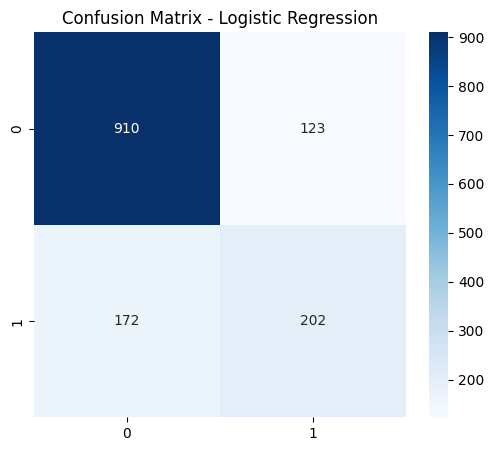


✅ Bước 3 hoàn tất! Best model đã được lưu.


In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import seaborn as sns
import matplotlib.pyplot as plt
import os
import joblib

# ====================== Đường dẫn ======================
BASE_DIR = os.path.dirname(os.getcwd())
DATA_PATH = os.path.join(BASE_DIR, 'data/')
FIGURE_PATH = os.path.join(BASE_DIR, 'reports/figures/')
os.makedirs(FIGURE_PATH, exist_ok=True)

# Load data
X_train = pd.read_csv(DATA_PATH + 'X_train.csv')
X_test = pd.read_csv(DATA_PATH + 'X_test.csv')
y_train = pd.read_csv(DATA_PATH + 'y_train.csv').squeeze()
y_test = pd.read_csv(DATA_PATH + 'y_test.csv').squeeze()

# ====================== Train models ======================
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42),
    'XGBoost': xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, random_state=42)
}

results = []
best_model_name = None
best_f1 = 0
best_model = None

for name, model in models.items():
    print(f"Đang train {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)
    
    results.append([name, round(acc,4), round(prec,4), round(rec,4), round(f1,4), round(auc,4)])
    
    print(f"F1-score: {f1:.4f} | AUC: {auc:.4f}")
    
    if f1 > best_f1:
        best_f1 = f1
        best_model_name = name
        best_model = model

print(f"\n🏆 BEST MODEL: {best_model_name} (F1 = {best_f1:.4f})")

# Lưu best model
joblib.dump(best_model, os.path.join(BASE_DIR, 'src/best_model.pkl'))

# ====================== Kết quả so sánh ======================
results_df = pd.DataFrame(results, columns=['Model', 'Accuracy', 'Precision', 'Recall', 'F1', 'AUC'])
print("\n=== BẢNG SO SÁNH ===")
print(results_df)
results_df.to_csv(os.path.join(BASE_DIR, 'reports/model_comparison.csv'), index=False)

# Confusion Matrix của Best Model
y_pred_best = best_model.predict(X_test)
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.savefig(os.path.join(FIGURE_PATH, 'confusion_matrix_best.png'))
plt.show()

print("\n✅ Bước 3 hoàn tất! Best model đã được lưu.")